In [2]:
import numpy as np
import plotly.graph_objects as go


In [3]:
# =====================================================================
# R-2000iC/125L Motion Limits (B-83644EN/03)
# =====================================================================

class Constraint:
    """A single motion-limit constraint: coeffs . [J2, J3] = value."""

    def __init__(self, coeffs, value, note):
        self.coeffs = np.array(coeffs)
        self.value = value
        self.note = note   # the name/label from the diagram

    @property
    def row(self):
        # [J2 coeff, J3 coeff, value]
        return np.append(self.coeffs, self.value)

    @property
    def equation_row(self):
        # last column negated -> coeffs . [J2, J3] - value = 0
        return np.append(self.coeffs, -self.value)

    def __repr__(self):
        return (f"Constraint(coeffs={self.coeffs.tolist()}, "
                f"value={self.value}, note={self.note!r})")
    
    @property
    def equation_string(self):
        """Human-readable equation string, e.g. 'J2 = -60' or 'J2 + J3 = +180'."""
        terms = []
        for coef, var in zip(self.coeffs, ["J2", "J3"]):
            if coef == 0:
                continue
            mag = abs(coef) if abs(coef) != 1 else ""
            if not terms:                       # first term keeps its own sign
                terms.append(f"{'-' if coef < 0 else ''}{mag}{var}")
            else:                               # later terms get explicit + / -
                terms.append(f"{'-' if coef < 0 else '+'} {mag}{var}")
        lhs = " ".join(terms) if terms else "0"
        return f"{lhs} = {self.value:+g}"


# ---------------------------------------------------------------------
# Table 1: J2-axis motion limit (constrains J2 only -> J3 coeff = 0)
# ---------------------------------------------------------------------
table1_j2 = [
    Constraint([1, 0], -60, "Stroke end (Lower limit)"),
    Constraint([1, 0], +76, "Stroke end (Upper limit)"),
    Constraint([1, 0], -66, "Maximum stopping distance (position)"),
    Constraint([1, 0], +80, "Maximum stopping distance (position)"),
]

# ---------------------------------------------------------------------
# Table 2: J3-axis motion limit (J2 + J3 combined)
# ---------------------------------------------------------------------
table2_j3 = [
    Constraint([1, 1],  -79, "Stroke end (Lower limit)"),
    Constraint([1, 1],  -83, "Maximum stopping distance (position)"),
    Constraint([1, 1], +180, "Stroke end (Upper limit)"),
    Constraint([1, 1], +184, "Maximum stopping distance (position)"),
]

In [4]:
def graph_constraints(constraints, title="Motion-limit constraints", view=(-200, 200)):
    """Plot each constraint as a full-width line in the (J2, J3) plane."""
    lo, hi = view
    span = (hi - lo) * 5                 # draw well beyond the viewport
    t = np.linspace(lo - span, hi + span, 2)

    fig = go.Figure()
    for c in constraints:
        a2, a3 = c.coeffs
        if a3 == 0:                      # vertical: a2*J2 = value
            xv = c.value / a2
            x, y = [xv, xv], [t[0], t[-1]]
        else:                            # J3 = (value - a2*J2) / a3
            x, y = t, (c.value - a2 * t) / a3
        fig.add_trace(go.Scatter(x=x, y=y, mode="lines",
                                 name=f"{c.value:+g}: {c.note}"))

    fig.update_layout(
        title=title,
        xaxis=dict(title="J2 (deg)", range=view, scaleanchor="y", scaleratio=1),
        yaxis=dict(title="J3 (deg)", range=view),
    )
    return fig


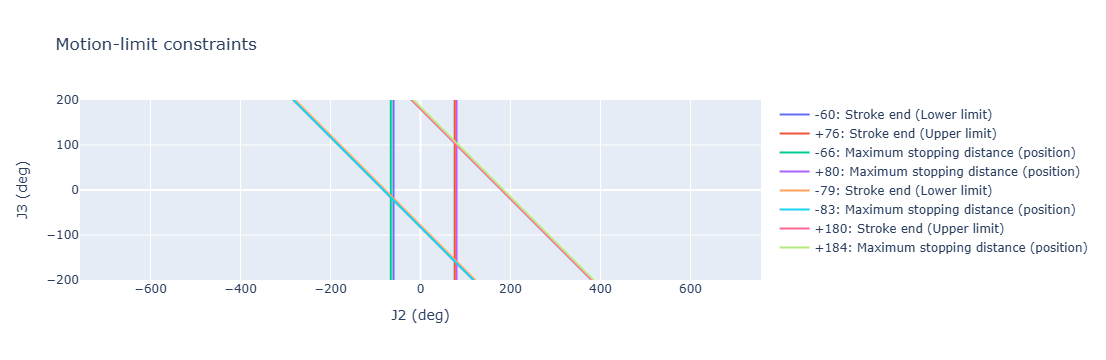

In [5]:
combined = table1_j2 + table2_j3          # concatenate the two lists here

graph_constraints(combined).show()

In [6]:
import numpy as np
import plotly.graph_objects as go


class Robot:
    """Robot link geometry in the zero position.

    Link distances are given as (x, y) offsets:
      - j2_to_j3: (x, y) from joint J2 to joint J3
      - j3_to_j5: (x, y) from joint J3 to joint J5

    Joint positions (zero position), with J2 at the origin:
      J2 = (0, 0)
      J3 = J2 + j2_to_j3
      J5 = J3 + j3_to_j5
    """

    def __init__(self, j2_to_j3=(0, 1075), j3_to_j5=(1730, 225)):
        self.j2_to_j3 = np.array(j2_to_j3, dtype=float)   # (x, y)
        self.j3_to_j5 = np.array(j3_to_j5, dtype=float)   # (x, y)

    @property
    def j2(self):
        return np.array([0.0, 0.0])

    @property
    def j3(self):
        return self.j2 + self.j2_to_j3

    @property
    def j5(self):
        return self.j3 + self.j3_to_j5

    def _manhattan_path(self, start, end):
        """Return x, y coords of an L-shaped path: y-segment then x-segment."""
        corner = np.array([start[0], end[1]])      # travel in y first, then x
        xs = [start[0], corner[0], end[0]]
        ys = [start[1], corner[1], end[1]]
        return xs, ys

    def plot_links(self, fig=None, title="Robot links (Manhattan space)"):
        """Draw each joint-pair link as a Manhattan path, each a different color."""
        if fig is None:
            fig = go.Figure()

        links = [
            ("J2 \u2192 J3", self.j2, self.j3),
            ("J3 \u2192 J5", self.j3, self.j5),
        ]
        for name, start, end in links:
            xs, ys = self._manhattan_path(start, end)
            fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines+markers", name=name))

        fig.update_layout(
            title=title,
            xaxis=dict(title="x", scaleanchor="y", scaleratio=1),
            yaxis=dict(title="y"),
        )
        return fig

In [7]:
the_robot = Robot()

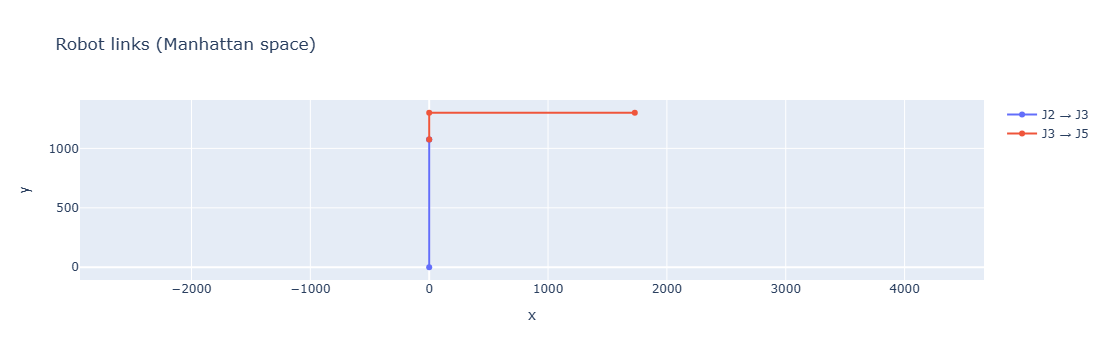

In [8]:
the_robot.plot_links().show()

In [9]:
def graph_robot_position(j2, j3, robot, title=None, size=600, pad=200):
    """Plot one robot pose for input joint angles (degrees), each link a different color,
    rendered as a rotated Manhattan L. The plot area is forced square."""
    def rot_cw(deg):
        t = np.deg2rad(deg); c, s = np.cos(t), np.sin(t)
        return np.array([[c, s], [-s, c]])

    def rot_ccw(deg):
        t = np.deg2rad(deg); c, s = np.cos(t), np.sin(t)
        return np.array([[c, -s], [s, c]])

    def manhattan_rotated(start, offset, R):
        dx, dy = offset
        local = np.array([[0, 0], [0, dy], [dx, dy]], float)
        return start + local @ R.T

    p2 = robot.j2
    link1 = manhattan_rotated(p2, robot.j2_to_j3, rot_cw(j2))
    p3 = link1[-1]
    link2 = manhattan_rotated(p3, robot.j3_to_j5, rot_ccw(j3))

    # square window: center on the data, side = largest span + padding
    pts = np.vstack([link1, link2])
    cx, cy = pts.mean(axis=0)
    half = (pts.max(axis=0) - pts.min(axis=0)).max() / 2 + pad
    xr = [cx - half, cx + half]
    yr = [cy - half, cy + half]

    fig = go.Figure()
    for pts_, name in [(link1, "J2 \u2192 J3"), (link2, "J3 \u2192 J5")]:
        fig.add_trace(go.Scatter(x=pts_[:, 0], y=pts_[:, 1],
                                 mode="lines+markers", name=name))
    fig.update_layout(
        title=title or f"Robot pose (J2={j2}\u00b0, J3={j3}\u00b0)",
        width=size, height=size,                       # square figure
        xaxis=dict(title="x", range=xr, scaleanchor="y", scaleratio=1),
        yaxis=dict(title="y", range=yr),
    )
    return fig

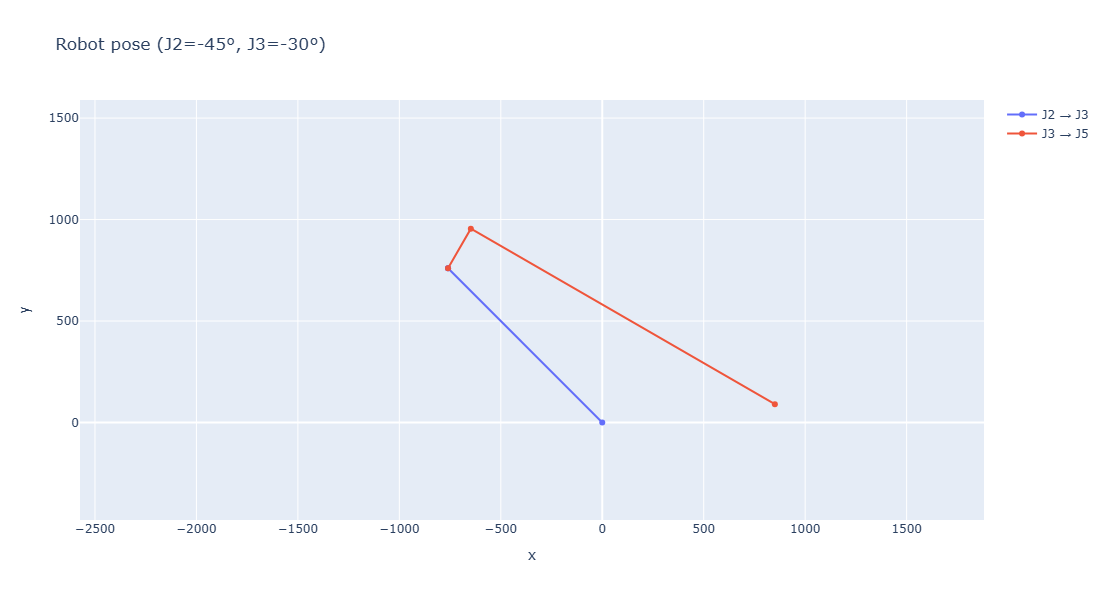

In [10]:
graph_robot_position(-45, -30, the_robot).show()

In [11]:
def graph_constraint_p5_sweep(constraints, robot, n=100, j3_range=(-360, 360),
                              title=None, width=900, height=900):
    """For each constraint, sweep J3 over j3_range (n points), solve J2 from the
    constraint (a2*J2 + a3*J3 = value -> J2 = (value - a3*J3)/a2), compute p5 at each
    step via the rotation FK, and plot the n p5 points as a line. One color per constraint.
    """
    def rot_cw(d):
        t = np.deg2rad(d); c, s = np.cos(t), np.sin(t)
        return np.array([[c, s], [-s, c]])

    def rot_ccw(d):
        t = np.deg2rad(d); c, s = np.cos(t), np.sin(t)
        return np.array([[c, -s], [s, c]])

    def p5_of(j2, j3):
        p3 = robot.j2 + rot_cw(j2) @ robot.j2_to_j3
        return p3 + rot_ccw(j3) @ robot.j3_to_j5

    j3s = np.linspace(j3_range[0], j3_range[1], n)

    fig = go.Figure()
    for c in constraints:
        a2, a3 = c.coeffs
        assert a2 != 0, f"Cannot solve J2: a2 == 0 for constraint {c.equation_string} ({c.note})"
        j2s = (c.value - a3 * j3s) / a2
        pts = np.array([p5_of(j2, j3) for j2, j3 in zip(j2s, j3s)])
        fig.add_trace(go.Scatter(x=pts[:, 0], y=pts[:, 1], mode="lines",
                                 name=f"{c.equation_string}  ({c.note})"))

    fig.update_layout(
        title=title or "p5 swept over J3 per constraint",
        width=width, height=height,
        xaxis=dict(title="x", scaleanchor="y", scaleratio=1),
        yaxis=dict(title="y"))
    return fig

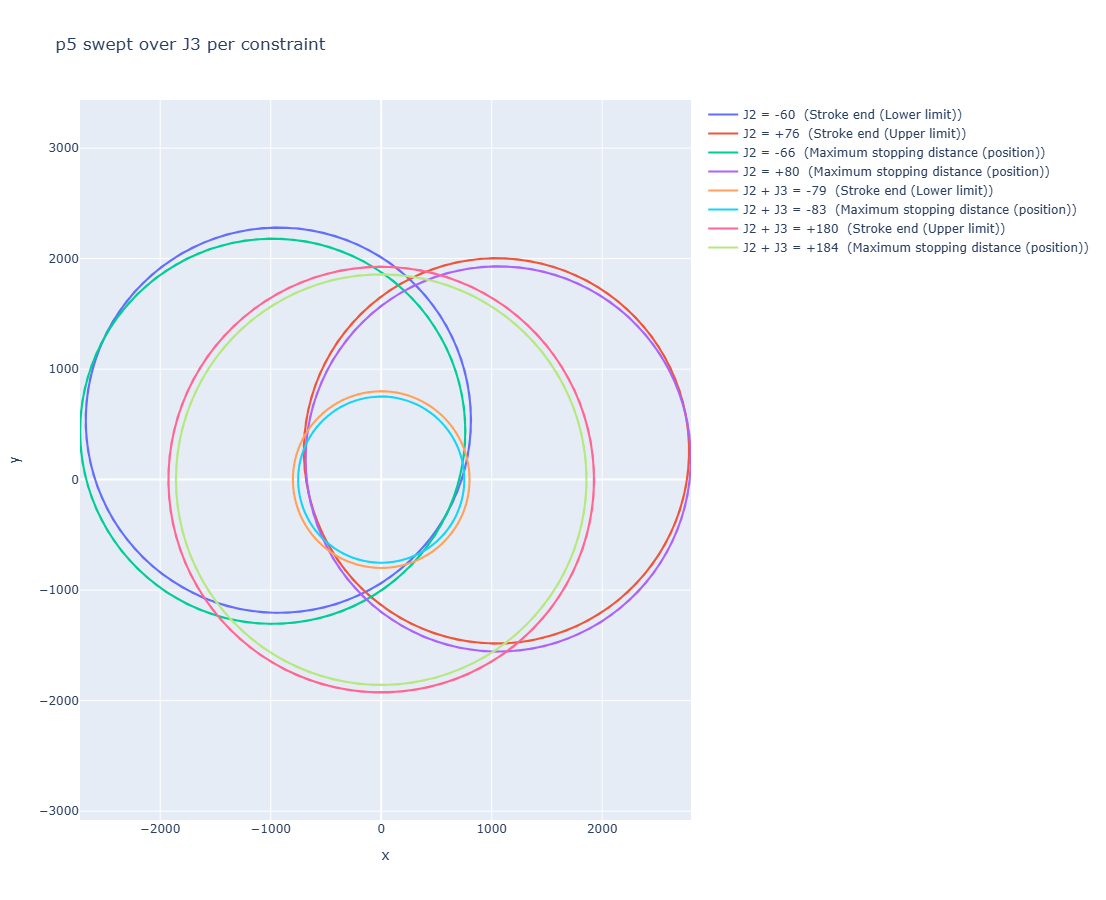

In [12]:
graph_constraint_p5_sweep(table1_j2 + table2_j3, the_robot).show()


In [13]:
# Stroke ends only — filter on the note, drop the maximum-stopping-distance entries
stroke_ends = [c for c in table1_j2 + table2_j3 if "Stroke end" in c.note]

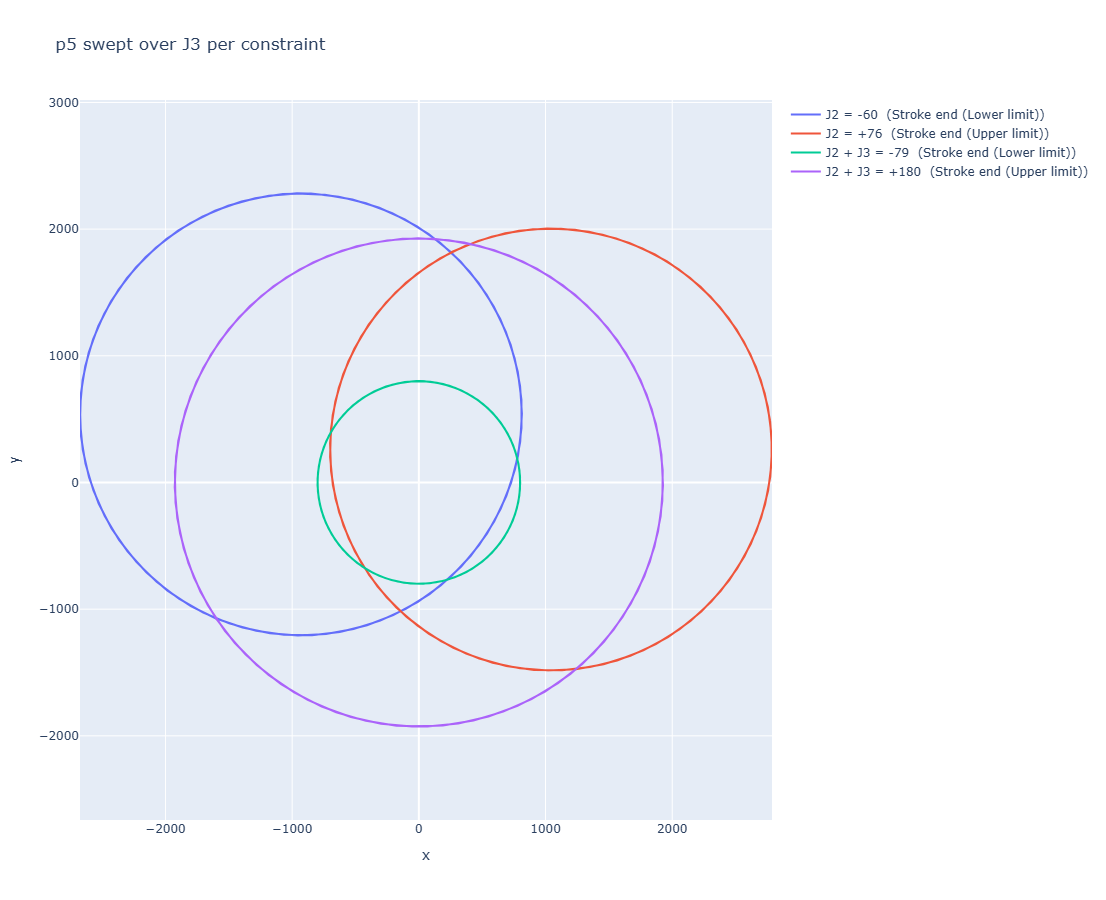

In [14]:
graph_constraint_p5_sweep(stroke_ends, the_robot).show()

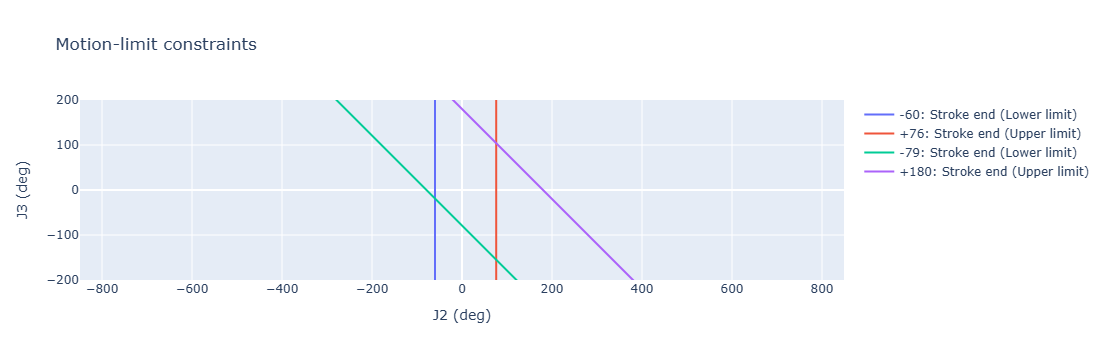

In [15]:
graph_constraints(stroke_ends).show()

In [16]:
import numpy as np
from itertools import combinations


class Vertex:
    """An intersection point of two constraint lines, in (J2, J3) space."""

    def __init__(self, point, constraints):
        self.point = np.asarray(point, float)     # (J2, J3)
        self.constraints = tuple(constraints)     # the two Constraints meeting here

    @property
    def j2(self):
        return self.point[0]

    @property
    def j3(self):
        return self.point[1]

    def __repr__(self):
        eqs = " & ".join(c.equation_string for c in self.constraints)
        return f"Vertex(J2={self.j2:.3f}, J3={self.j3:.3f} | {eqs})"


class ConstraintRegion:
    """Takes a list of constraints, finds their pairwise intersections, and
    keeps the vertex<->constraint relations for interpolation."""

    def __init__(self, constraints, tol=1e-9):
        self.constraints = list(constraints)
        self.tol = tol
        self.vertices = self._find_intersections()

    def _intersect(self, c1, c2):
        """Solve the 2x2 system for where two constraint lines cross; None if parallel."""
        A = np.array([c1.coeffs, c2.coeffs], float)
        b = np.array([c1.value, c2.value], float)
        if abs(np.linalg.det(A)) < self.tol:
            return None                            # parallel or coincident
        return np.linalg.solve(A, b)

    def _find_intersections(self):
        verts = []
        for c1, c2 in combinations(self.constraints, 2):
            p = self._intersect(c1, c2)
            if p is not None:
                verts.append(Vertex(p, (c1, c2)))
        return verts

    def vertices_on(self, constraint):
        """Relation: all intersection vertices lying on a given constraint line."""
        return [v for v in self.vertices if constraint in v.constraints]

    @property
    def relations(self):
        """Map each constraint -> the vertices (endpoints) on it."""
        return {c: self.vertices_on(c) for c in self.constraints}

    def _ordered_points(self):
        """Vertices ordered by angle around their centroid (closed-polygon order)."""
        pts = np.array([v.point for v in self.vertices])
        c = pts.mean(axis=0)
        ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
        return pts[np.argsort(ang)]

    @property
    def polygon_string(self):
        """Two-row closed-polygon string: row 1 = J2 coords, row 2 = J3 coords,
        tab-separated, 7 decimals, first vertex repeated to close the loop."""
        pts = self._ordered_points()
        pts = np.vstack([pts, pts[0]])             # close the loop
        row_x = "\t".join(f"{x:.7f}" for x in pts[:, 0])
        row_y = "\t".join(f"{y:.7f}" for y in pts[:, 1])
        return f"{row_x}\n{row_y}"

    def interpolate(self, n=100):
        """Sample n (J2, J3) points evenly (by arc length) around the closed
        region polygon, walking edge to edge between intersection vertices."""
        pts = self._ordered_points()
        pts = np.vstack([pts, pts[0]])                 # close the loop
        seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
        cum = np.concatenate([[0], np.cumsum(seg)])
        s = np.linspace(0, cum[-1], n)
        j2 = np.interp(s, cum, pts[:, 0])
        j3 = np.interp(s, cum, pts[:, 1])
        return np.column_stack([j2, j3])

In [17]:
region = ConstraintRegion(stroke_ends)
print(region.polygon_string)


-60.0000000	76.0000000	76.0000000	-60.0000000	-60.0000000
-19.0000000	-155.0000000	104.0000000	240.0000000	-19.0000000


In [18]:
region.relations            # constraint -> [endpoints]

{Constraint(coeffs=[1, 0], value=-60, note='Stroke end (Lower limit)'): [Vertex(J2=-60.000, J3=-19.000 | J2 = -60 & J2 + J3 = -79),
  Vertex(J2=-60.000, J3=240.000 | J2 = -60 & J2 + J3 = +180)],
 Constraint(coeffs=[1, 0], value=76, note='Stroke end (Upper limit)'): [Vertex(J2=76.000, J3=-155.000 | J2 = +76 & J2 + J3 = -79),
  Vertex(J2=76.000, J3=104.000 | J2 = +76 & J2 + J3 = +180)],
 Constraint(coeffs=[1, 1], value=-79, note='Stroke end (Lower limit)'): [Vertex(J2=-60.000, J3=-19.000 | J2 = -60 & J2 + J3 = -79),
  Vertex(J2=76.000, J3=-155.000 | J2 = +76 & J2 + J3 = -79)],
 Constraint(coeffs=[1, 1], value=180, note='Stroke end (Upper limit)'): [Vertex(J2=-60.000, J3=240.000 | J2 = -60 & J2 + J3 = +180),
  Vertex(J2=76.000, J3=104.000 | J2 = +76 & J2 + J3 = +180)]}

In [19]:
def graph_polygon_string(polygon_string, title="Polygon from polygon_string"):
    """Parse a two-row polygon_string (row1 = J2 coords, row2 = J3 coords,
    tab-separated, closed) and plot the closed loop with vertices numbered."""
    rows = polygon_string.strip().split("\n")
    xs = [float(v) for v in rows[0].split("\t")]
    ys = [float(v) for v in rows[1].split("\t")]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines+markers", name="polygon"))
    # number each vertex (skip the repeated closing point)
    fig.add_trace(go.Scatter(
        x=xs[:-1], y=ys[:-1], mode="text",
        text=[str(i) for i in range(len(xs) - 1)],
        textposition="top right", showlegend=False))
    fig.update_layout(
        title=title,
        xaxis=dict(title="J2", scaleanchor="y", scaleratio=1),
        yaxis=dict(title="J3"))
    return fig

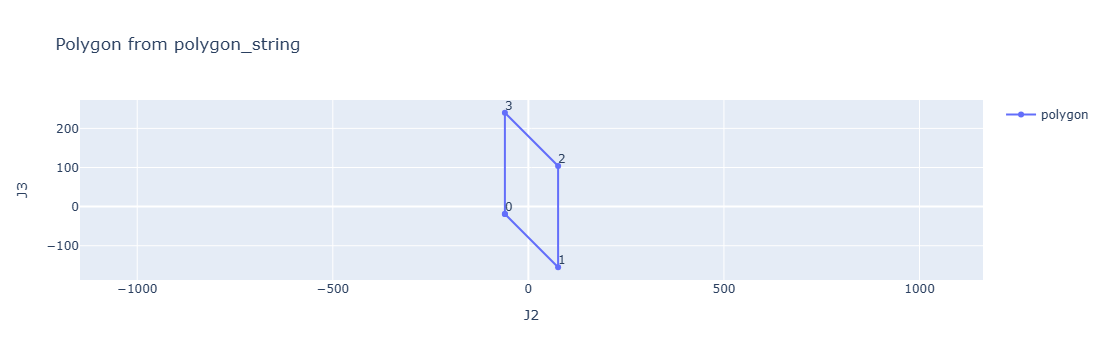

In [20]:
graph_polygon_string(region.polygon_string).show()

In [21]:
def max_reach_constraint(robot, note="max reach (links colinear)"):
    """Generate the constraint J2 + J3 = (alpha1 - alpha2) that puts the two links
    colinear, maximizing |p5| (reach = |link1| + |link2|).
    alpha1, alpha2 are the native offset headings atan2(y, x) of each link."""
    a1 = np.degrees(np.arctan2(robot.j2_to_j3[1], robot.j2_to_j3[0]))
    a2 = np.degrees(np.arctan2(robot.j3_to_j5[1], robot.j3_to_j5[0]))
    return Constraint([1, 1], a1 - a2, note)

In [22]:
def graph_region_on_robot(region, robot, n=100, title=None,
                          width=900, height=900, show_robot=True):
    """Interpolate n (J2, J3) points around the region polygon, map each to p5
    via the rotation FK, and graph the resulting workspace loop in robot space."""
    def rot_cw(d):
        t = np.deg2rad(d); c, s = np.cos(t), np.sin(t)
        return np.array([[c, s], [-s, c]])

    def rot_ccw(d):
        t = np.deg2rad(d); c, s = np.cos(t), np.sin(t)
        return np.array([[c, -s], [s, c]])

    def p5_of(j2, j3):
        p3 = robot.j2 + rot_cw(j2) @ robot.j2_to_j3
        return p3 + rot_ccw(j3) @ robot.j3_to_j5

    angles = region.interpolate(n)
    pts = np.array([p5_of(j2, j3) for j2, j3 in angles])

    fig = go.Figure()
    if show_robot:
        p3z = robot.j2 + robot.j2_to_j3
        p5z = p3z + robot.j3_to_j5
        fig.add_trace(go.Scatter(
            x=[robot.j2[0], p3z[0], p5z[0]], y=[robot.j2[1], p3z[1], p5z[1]],
            mode="lines", line=dict(color="lightgray", width=2, dash="dot"),
            name="robot (zero pos)"))
    fig.add_trace(go.Scatter(x=pts[:, 0], y=pts[:, 1], mode="lines",
                             name="p5 along region boundary"))
    fig.update_layout(
        title=title or "Region boundary mapped to p5",
        width=width, height=height,
        xaxis=dict(title="x", scaleanchor="y", scaleratio=1),
        yaxis=dict(title="y"))
    return fig

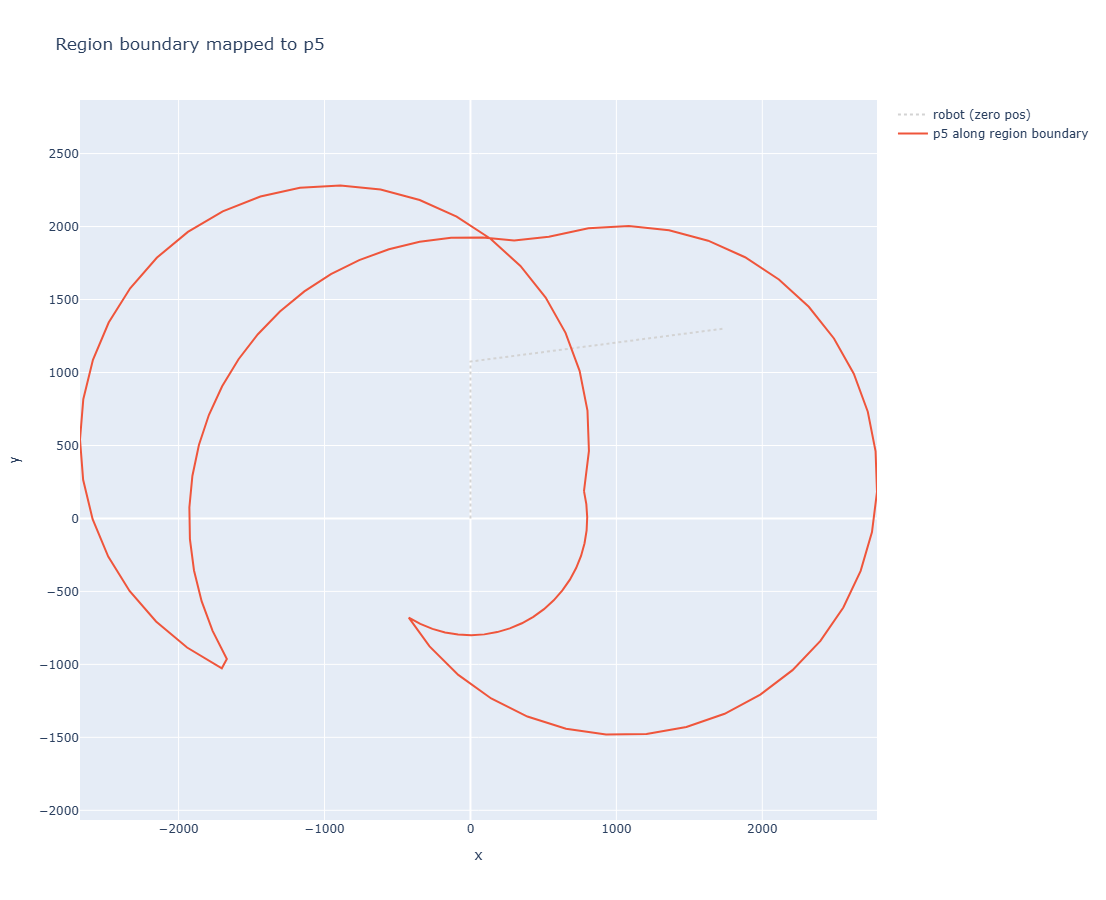

In [23]:
graph_region_on_robot(region, the_robot, n=100).show()

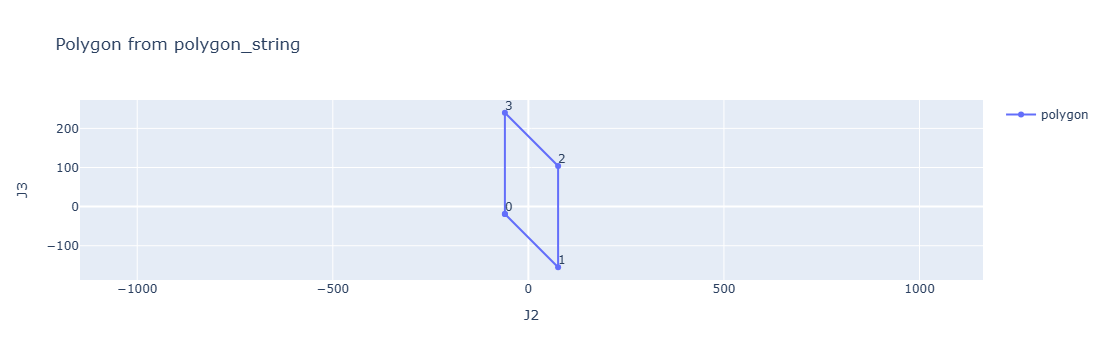

In [24]:
graph_polygon_string(region.polygon_string).show()

In [25]:
mrc = max_reach_constraint(the_robot)

In [26]:
mrc

Constraint(coeffs=[1, 1], value=82.58983104163686, note='max reach (links colinear)')

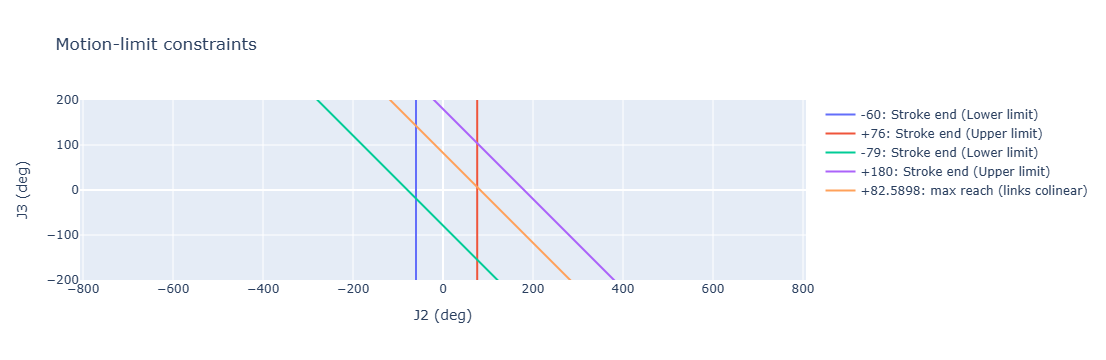

In [27]:
graph_constraints(stroke_ends+[mrc]).show()

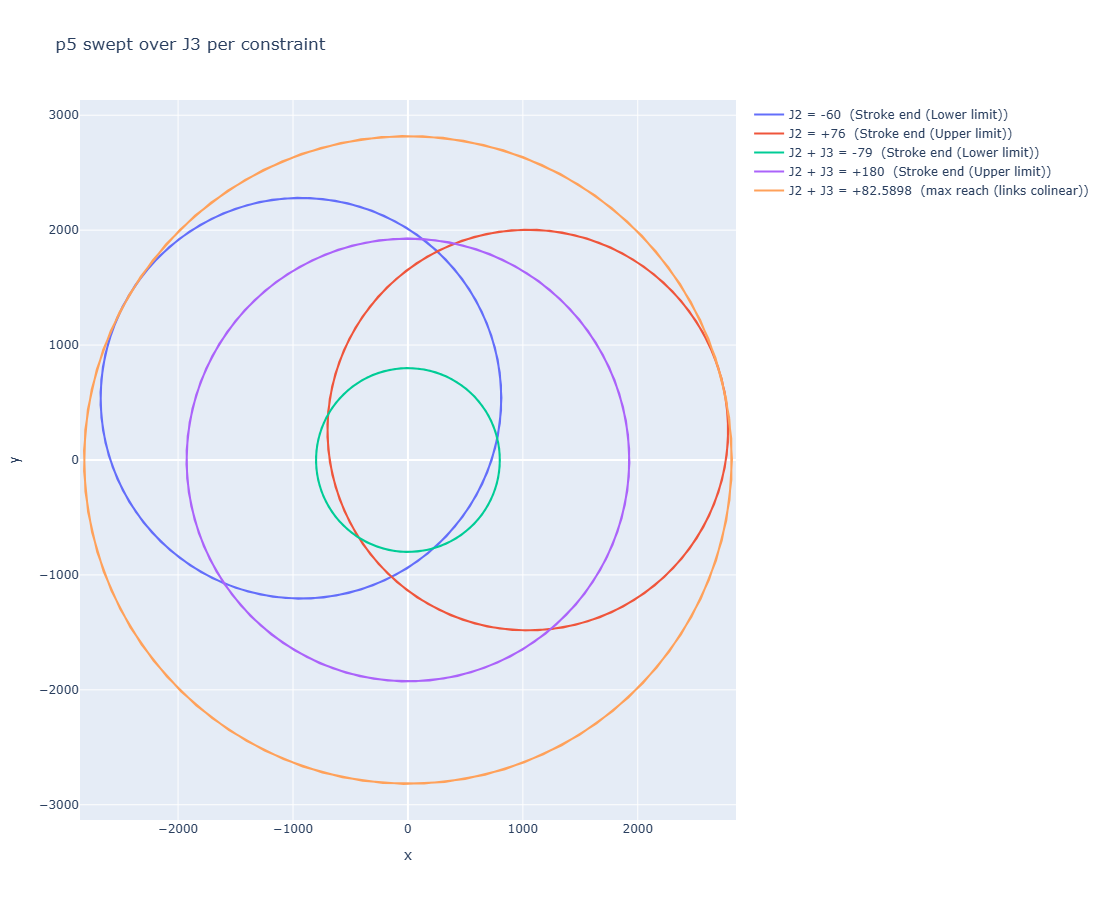

In [28]:
graph_constraint_p5_sweep(stroke_ends+[mrc], the_robot).show()

In [29]:
class ClippedRegion(ConstraintRegion):
    """Keeps the base region unchanged AND the segment of the added constraint's
    line that lies inside the region (its chord). Nothing else: the region isn't
    trimmed, and the line isn't extended past the region boundary."""

    def __init__(self, region, constraint, tol=1e-9):
        self.base_region = region
        self.added_constraint = constraint
        super().__init__(region.constraints + [constraint], tol=tol)
        self.chord = self._chord(region, constraint)

    def _chord(self, region, constraint):
        """Endpoints where the constraint line enters/exits the region polygon."""
        poly = region._ordered_points()
        a2, a3 = constraint.coeffs
        v = constraint.value
        f = lambda p: a2 * p[0] + a3 * p[1] - v
        hits = []
        n = len(poly)
        for i in range(n):
            cur = poly[i]
            nxt = poly[(i + 1) % n]
            fc, fn = f(cur), f(nxt)
            if abs(fc) <= self.tol:                 # vertex sits on the line
                hits.append(cur)
            elif fc * fn < 0:                       # edge crosses the line
                t = fc / (fc - fn)
                hits.append(cur + t * (nxt - cur))
        if not hits:
            return np.empty((0, 2))                 # line misses the region entirely
        hits = np.array(hits)
        uniq = [hits[0]]                            # dedupe coincident hits
        for h in hits[1:]:
            if all(np.linalg.norm(h - u) > 1e-6 for u in uniq):
                uniq.append(h)
        return np.array(uniq)

    def _ordered_points(self):
        return self.base_region._ordered_points()   # region kept whole

    @property
    def chord_string(self):
        """Two-row string for the chord endpoints, same format as polygon_string."""
        rx = "\t".join(f"{x:.7f}" for x in self.chord[:, 0])
        ry = "\t".join(f"{y:.7f}" for y in self.chord[:, 1])
        return f"{rx}\n{ry}"

    def chord_interpolate(self, n=100):
        """n (J2, J3) points evenly along the chord (empty if the line missed)."""
        if len(self.chord) < 2:
            return np.empty((0, 2))
        a, b = self.chord[0], self.chord[1]
        t = np.linspace(0, 1, n)[:, None]
        return a + (b - a) * t

In [30]:
cr = ClippedRegion(ConstraintRegion(stroke_ends), mrc)

In [31]:
def graph_clipped_region(cr, title="Clipped region (J2, J3)", width=600, height=900):
    """Plot the kept region polygon (filled) and the constraint chord in (J2, J3) space."""
    poly = cr._ordered_points()
    poly = np.vstack([poly, poly[0]])

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=poly[:, 0], y=poly[:, 1],
                             mode="lines+markers", fill="toself",
                             name="region (kept whole)"))
    if len(cr.chord) >= 2:
        fig.add_trace(go.Scatter(x=cr.chord[:, 0], y=cr.chord[:, 1],
                                 mode="lines+markers", line=dict(color="red", width=3),
                                 name=f"chord: {cr.added_constraint.equation_string}"))
    fig.update_layout(
        title=title,
        width=width, height=height,
        xaxis=dict(title="J2 (deg)", scaleanchor="y", scaleratio=1),
        yaxis=dict(title="J3 (deg)"))
    return fig

In [32]:
def graph_clipped_region_on_robot(cr, robot, n=100, title="Clipped region on robot",
                                  width=900, height=900, show_robot=True):
    """Map the region boundary and the constraint chord to p5 via the rotation FK."""
    def rot_cw(d):
        t = np.deg2rad(d); c, s = np.cos(t), np.sin(t)
        return np.array([[c, s], [-s, c]])

    def rot_ccw(d):
        t = np.deg2rad(d); c, s = np.cos(t), np.sin(t)
        return np.array([[c, -s], [s, c]])

    def p5_of(j2, j3):
        p3 = robot.j2 + rot_cw(j2) @ robot.j2_to_j3
        return p3 + rot_ccw(j3) @ robot.j3_to_j5

    region_p5 = np.array([p5_of(j2, j3) for j2, j3 in cr.interpolate(n)])
    chord_xy = cr.chord_interpolate(n)
    chord_p5 = np.array([p5_of(j2, j3) for j2, j3 in chord_xy]) if len(chord_xy) else chord_xy

    fig = go.Figure()
    if show_robot:
        p3z = robot.j2 + robot.j2_to_j3
        p5z = p3z + robot.j3_to_j5
        fig.add_trace(go.Scatter(
            x=[robot.j2[0], p3z[0], p5z[0]], y=[robot.j2[1], p3z[1], p5z[1]],
            mode="lines", line=dict(color="lightgray", width=2, dash="dot"),
            name="robot (zero pos)"))
    fig.add_trace(go.Scatter(x=region_p5[:, 0], y=region_p5[:, 1],
                             mode="lines", name="region boundary \u2192 p5"))
    if len(chord_p5):
        fig.add_trace(go.Scatter(x=chord_p5[:, 0], y=chord_p5[:, 1],
                                 mode="lines", line=dict(color="red", width=3),
                                 name="chord \u2192 p5"))
    fig.update_layout(
        title=title, width=width, height=height,
        xaxis=dict(title="x", scaleanchor="y", scaleratio=1),
        yaxis=dict(title="y"))
    return fig

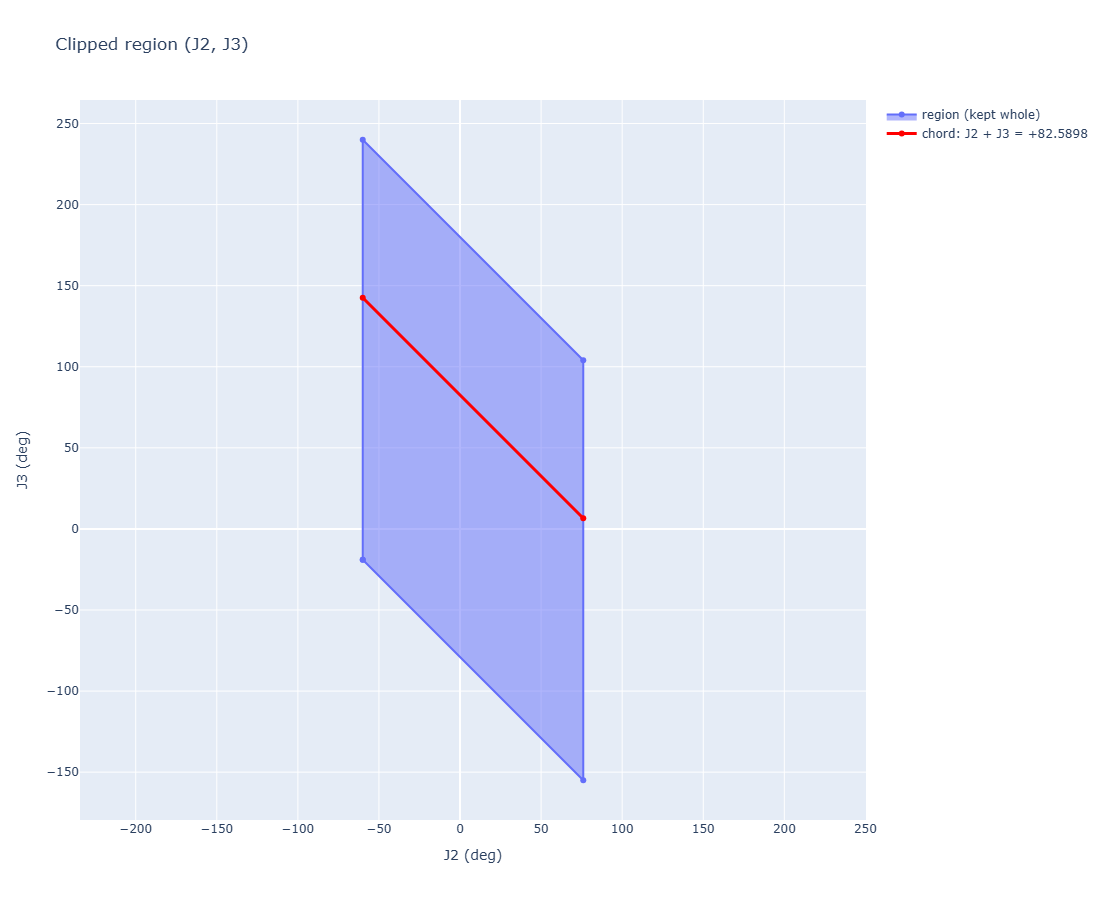

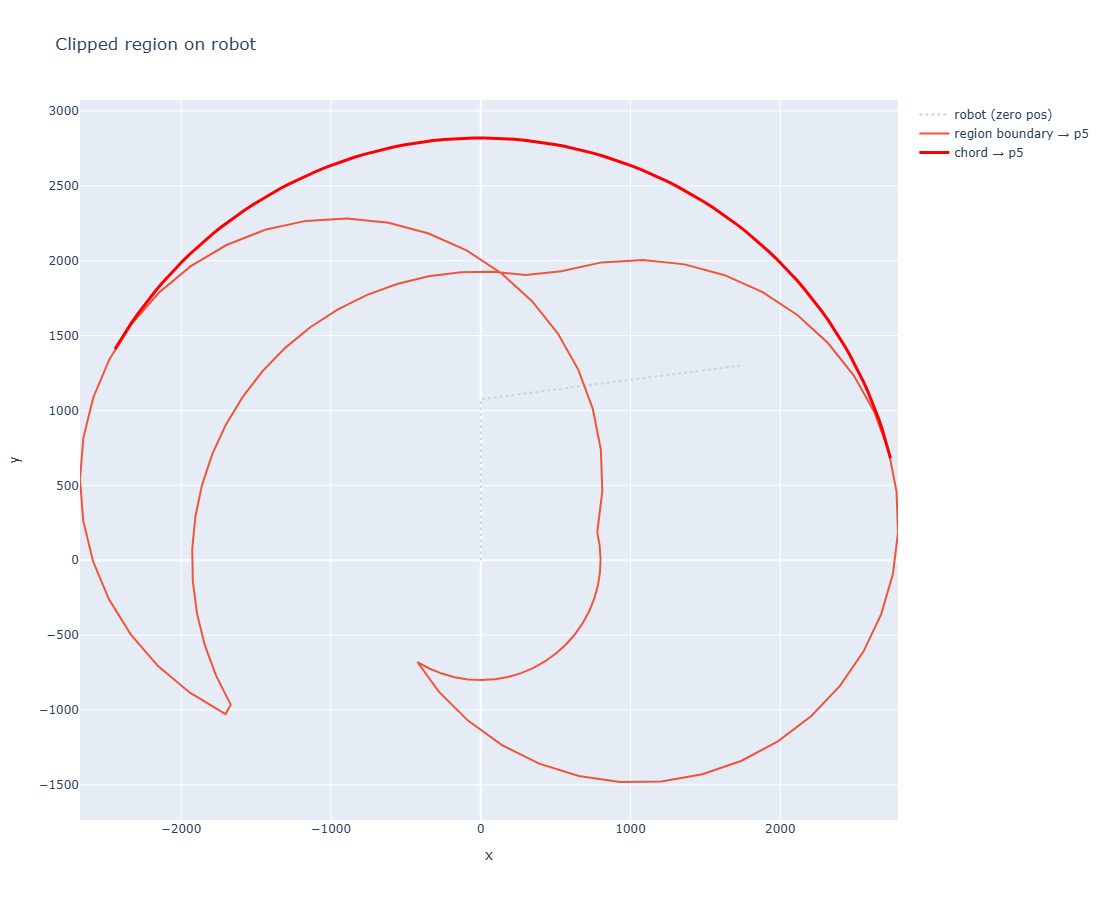

In [33]:
graph_clipped_region(cr).show()
graph_clipped_region_on_robot(cr, the_robot, n=100).show()

In [ ]:
class PolygonRegion(ClippedRegion):
    """A ClippedRegion built directly from a polygon_string (the same two-row,
    whitespace-separated, closed-loop format that ConstraintRegion.polygon_string
    emits) plus an added Constraint (e.g. the max-reach constraint). Each edge
    of the polygon becomes an implicit Constraint so the parent interface
    (interpolate, relations, polygon_string) keeps working, and the added
    constraint's chord through the polygon is computed the same way the parent
    does it."""

    def __init__(self, polygon_string, constraint, tol=1e-9):
        pts = self._parse_polygon_string(polygon_string)
        self.tol = tol
        self._polygon = pts
        # Vertices come straight from the polygon — skip pairwise intersection
        # discovery since we already have them ordered.
        self.vertices = [Vertex(p, ()) for p in pts]
        self.constraints = self._edges_to_constraints(pts) + [constraint]
        self.base_region = None
        self.added_constraint = constraint
        # _chord() only needs a ._ordered_points() callable — pass self.
        self.chord = self._chord(self, constraint)

    @staticmethod
    def _parse_polygon_string(s):
        rows = s.strip().split("\n")
        xs = np.array([float(v) for v in rows[0].split()])
        ys = np.array([float(v) for v in rows[1].split()])
        pts = np.column_stack([xs, ys])
        if len(pts) > 1 and np.allclose(pts[0], pts[-1]):
            pts = pts[:-1]
        return pts

    @staticmethod
    def _edges_to_constraints(pts):
        cs = []
        n = len(pts)
        for i in range(n):
            a = pts[i]
            b = pts[(i + 1) % n]
            dx, dy = b - a
            # Line through a,b: (-dy)*J2 + (dx)*J3 = (-dy)*a[0] + (dx)*a[1]
            n_j2, n_j3 = -dy, dx
            value = n_j2 * a[0] + n_j3 * a[1]
            cs.append(Constraint([n_j2, n_j3], value, f"edge {i}→{(i+1)%n}"))
        return cs

    def _ordered_points(self):
        return self._polygon

In [ ]:
poly_str = (
    "-60.0000000\t-60.0000000\t0.0000000\t76.0000000\t76.0000000\t42.0000000\t-60.0000000\n"
    "-19.0000000\t180.0000000\t180.0000000\t104.0000000\t-121.0000000\t-121.0000000\t-19.0000000"
)
pr = PolygonRegion(poly_str, mrc)
print(pr.polygon_string)
graph_clipped_region(pr).show()

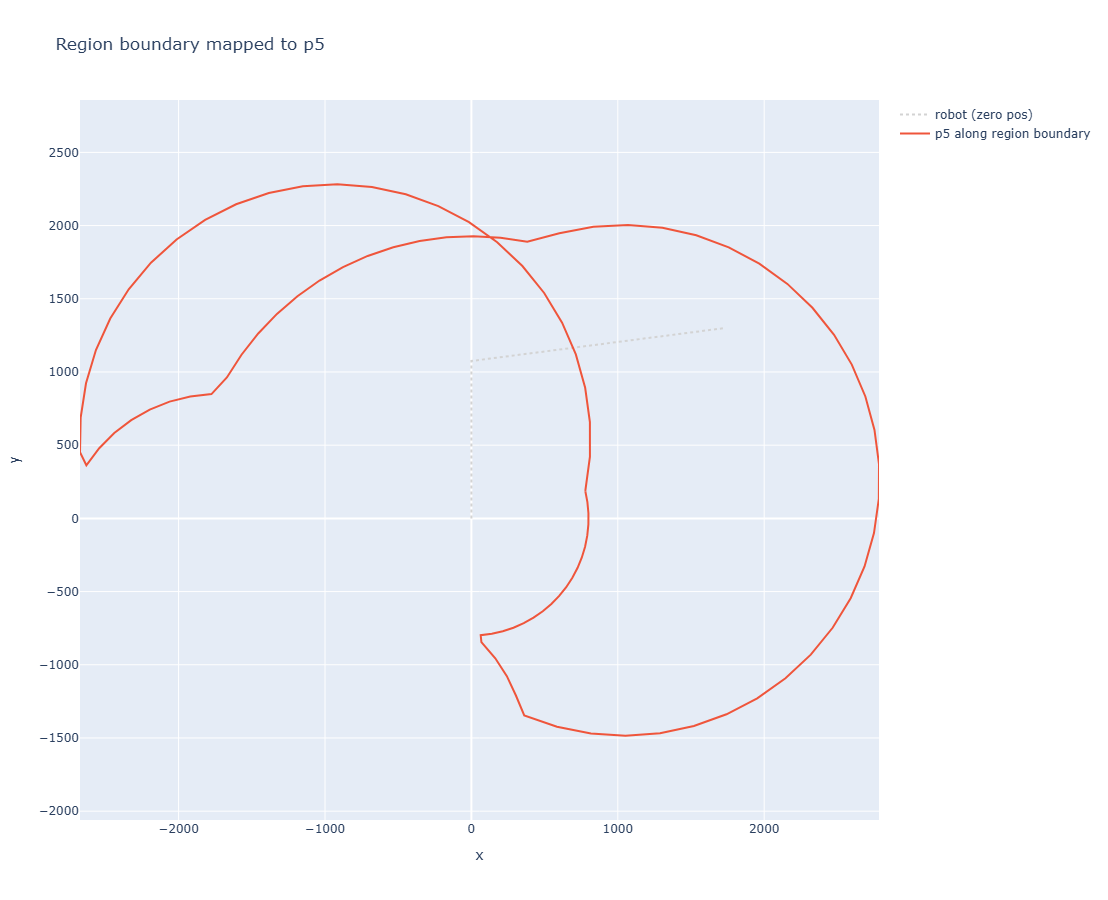

In [38]:
graph_region_on_robot(pr, the_robot, n=100).show()